<a href="https://colab.research.google.com/github/hamzali369/Regression-anaylsis/blob/main/HAT_matrix_%2C_levarage_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load real dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Select a few predictors
X = df[['MedInc', 'HouseAge', 'AveRooms']]

# Add intercept column manually
X.insert(0, 'Intercept', 1)

# Convert to numpy array
X_matrix = X.values

# Response variable
y = housing.target

# Compute Hat Matrix
# H = X(X'X)^(-1)X'

XtX = X_matrix.T @ X_matrix

XtX_inv = np.linalg.inv(XtX)

H = X_matrix @ XtX_inv @ X_matrix.T

print("Shape of Hat Matrix:")
print(H.shape)

# Predicted Values using Hat Matrix
# y_hat = Hy

y_hat = H @ y

print("\nFirst 5 Predicted Values:")
print(y_hat[:5])

# Leverage Values
# diagonal elements of H

leverage = np.diag(H)

print("\nFirst 10 Leverage Values:")
print(leverage[:10])

# Detect High Leverage Points
# Rule: h_ii > 2p/n


n = X_matrix.shape[0]
p = X_matrix.shape[1]

threshold = (2 * p) / n

high_leverage_points = np.where(leverage > threshold)[0]

print(f"\nLeverage Threshold: {threshold}")

print("\nHigh Leverage Observation Indices:")
print(high_leverage_points[:20])

print(f"\nTotal High Leverage Points: {len(high_leverage_points)}")

Shape of Hat Matrix:
(20640, 20640)

First 5 Predicted Values:
[4.20656308 3.87983989 3.88341489 3.23575221 2.42753784]

First 10 Leverage Values:
[0.000393   0.00032967 0.00044906 0.00028117 0.00023503 0.00022042
 0.0002161  0.00021726 0.00013587 0.00021636]

Leverage Threshold: 0.0003875968992248062

High Leverage Observation Indices:
[  0   2  63 124 126 131 141 154 155 156 158 403 404 406 407 408 409 415
 490 493]

Total High Leverage Points: 757


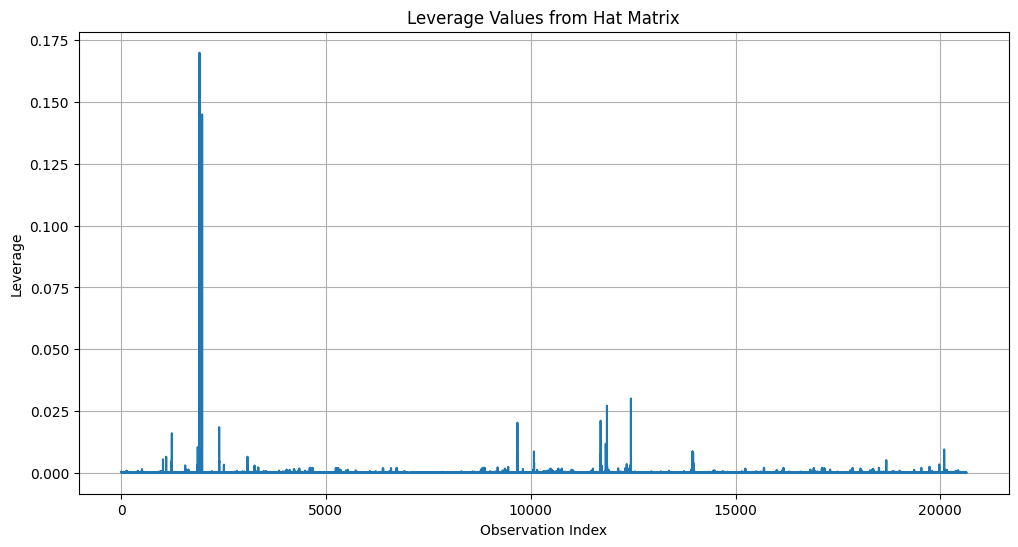

In [8]:
# first graph
plt.figure(figsize=(12,6))

plt.plot(leverage)

plt.title("Leverage Values from Hat Matrix")

plt.xlabel("Observation Index")

plt.ylabel("Leverage")

plt.grid(True)

plt.show()




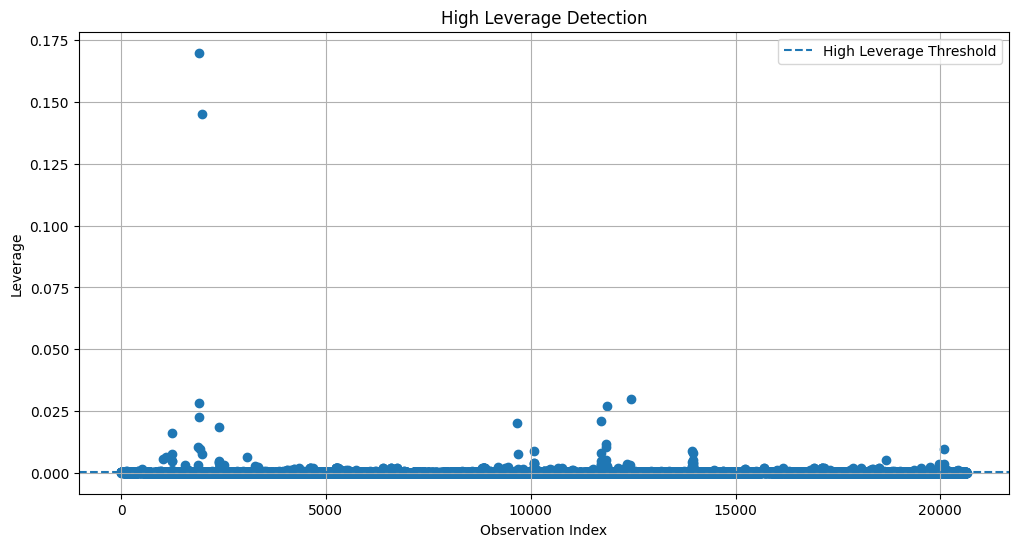

In [5]:
# Visualization 2: High Leverage Points

n = X_matrix.shape[0]
p = X_matrix.shape[1]

threshold = (2 * p) / n

high_leverage = leverage > threshold

plt.figure(figsize=(12,6))

plt.scatter(range(n), leverage)

plt.axhline(
    y=threshold,
    linestyle='--',
    label='High Leverage Threshold'
)

plt.title("High Leverage Detection")

plt.xlabel("Observation Index")

plt.ylabel("Leverage")

plt.legend()

plt.grid(True)

plt.show()

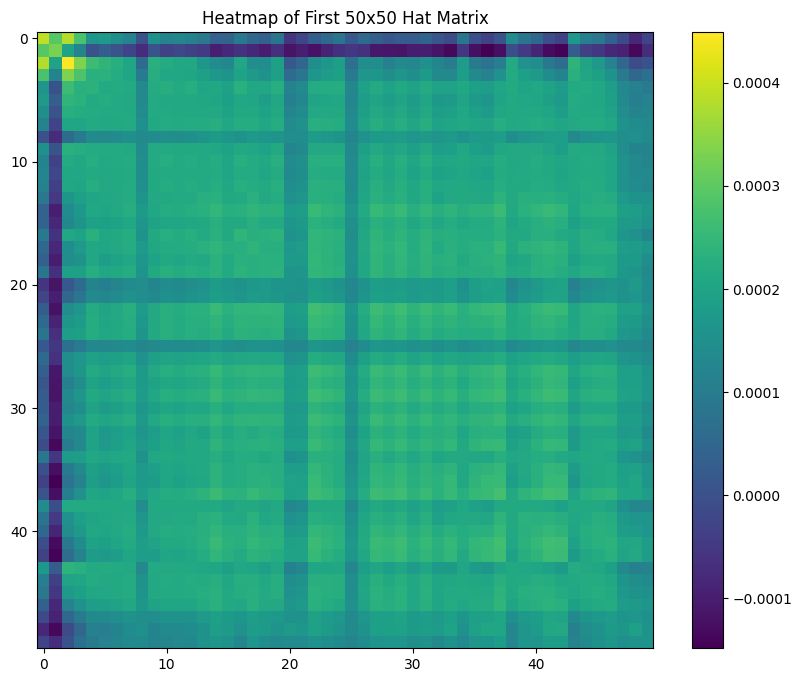

Shape of Hat Matrix: (20640, 20640)

First 10 Leverage Values:

[0.000393   0.00032967 0.00044906 0.00028117 0.00023503 0.00022042
 0.0002161  0.00021726 0.00013587 0.00021636]

Threshold for High Leverage: 0.0003875968992248062

Total High Leverage Points: 757


In [6]:
 #Visualization 3: Heatmap of Small Part of Hat Matrix


# Showing only first 50x50 values
small_H = H[:50, :50]

plt.figure(figsize=(10,8))

plt.imshow(small_H)

plt.colorbar()

plt.title("Heatmap of First 50x50 Hat Matrix")

plt.show()

# Print Some Information

print("Shape of Hat Matrix:", H.shape)

print("\nFirst 10 Leverage Values:\n")
print(leverage[:10])

print("\nThreshold for High Leverage:", threshold)

print("\nTotal High Leverage Points:",
      np.sum(high_leverage))

In [7]:
# Print Some Information

print("Shape of Hat Matrix:", H.shape)

print("\nFirst 10 Leverage Values:\n")
print(leverage[:10])

print("\nThreshold for High Leverage:", threshold)

print("\nTotal High Leverage Points:",
      np.sum(high_leverage))

Shape of Hat Matrix: (20640, 20640)

First 10 Leverage Values:

[0.000393   0.00032967 0.00044906 0.00028117 0.00023503 0.00022042
 0.0002161  0.00021726 0.00013587 0.00021636]

Threshold for High Leverage: 0.0003875968992248062

Total High Leverage Points: 757
